In [1]:
#Imports:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re 



In [2]:
#Read the file and pick the specific sheet that I want 
excelSheet = pd.ExcelFile('/Users/preciousajilore/Documents/GitHub/torchmtlr/data/finalforAIpredictionmodelfeb18 2.xlsx')
print(excelSheet.sheet_names)


['Sheet1']


In [3]:
df = pd.read_excel(
                  excelSheet,         # This is where you put the name of the excel file
                  sheet_name='Sheet1', # This is where you put the name of the sheet you want to read
                  engine='openpyxl')

In [4]:
#Sanity check time yurrr
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2066 entries, 0 to 2065
Data columns (total 62 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   UAH ID                    59 non-null     object        
 1   DOB (yyyy-mm-dd)          2066 non-null   object        
 2   Date of Surgery           2066 non-null   datetime64[ns]
 3   monthsurg                 1973 non-null   float64       
 4   Age (at time of surgery)  2065 non-null   float64       
 5   Age: <50 = 0; >= 50= 1    1973 non-null   object        
 6   stxlocation               2066 non-null   object        
 7   distal                    2065 non-null   float64       
 8   penile                    2064 non-null   float64       
 9   StxEtiology               2065 non-null   object        
 10  StxLength                 2065 non-null   object        
 11  # Strictures              2065 non-null   float64       
 12  charlsons           

In [7]:
print(df.isna().sum().sort_values(ascending= False).head(30))

UAH ID                    2007
failure date              1980
signifcomp                1724
minorcomp                 1677
cath removal              1617
BMI exact                 1128
SP complication           1025
satisfaction               679
cysto                      450
UTI  recurring             340
Persisting LUTS            328
ER visits                  322
Donor site                 319
Incontinence               276
LUTS                       271
Pain                       271
PVD                        269
Chordee                    268
foley                      257
complication               247
Stricture                  245
Abx                        245
UTI  Post                  238
Stricture intervention     233
fu                         191
erectilepost               187
claviangrade               179
LOS (days)                 128
 OR date                    95
Age: <50 = 0; >= 50= 1      93
dtype: int64


In [6]:
def info_as_table(df):
    """
    Return a DataFrame summarising what df.info() prints.
    Columns:
      col            – column name
      non-null       – # non-missing entries
      null           – # missing entries
      % null         – percentage missing
      dtype          – pandas dtype
      mem_kB         – memory used by the column (≈, index excluded)
    """
    non_null = df.count()
    nulls    = df.isna().sum()
    mem_kB   = df.memory_usage(index=False) / 1024  # KiB
    out = (
        pd.concat([non_null, nulls, mem_kB, df.dtypes], axis=1)
          .set_axis(["non_null", "null", "mem_kB", "dtype"], axis=1)
          .assign(**{"% null": lambda x: (x["null"] / len(df) * 100).round(1)})
          .reset_index(names="col")
    )
    return out[["col", "non_null", "null", "% null", "dtype", "mem_kB"]]


In [7]:
summary = info_as_table(df)
summary.head()
summary.style.format({"% null": "{:.1f}%", "mem_kB": "{:.1f}"})

,col,non_null,null,% null,dtype,mem_kB
0,UAH ID,59,2007,97.1%,object,16.1
1,DOB (yyyy-mm-dd),2066,0,0.0%,object,16.1
2,Date of Surgery,2066,0,0.0%,datetime64[ns],16.1
3,monthsurg,1973,93,4.5%,float64,16.1
4,Age (at time of surgery),2065,1,0.0%,float64,16.1
5,Age: <50 = 0; >= 50= 1,1973,93,4.5%,object,16.1
6,stxlocation,2066,0,0.0%,object,16.1
7,distal,2065,1,0.0%,float64,16.1
8,penile,2064,2,0.1%,float64,16.1
9,StxEtiology,2065,1,0.0%,object,16.1


The table above shows a couple things:
    - non_null : This is the number of rows in that column that actually have a value.
    - null : This is the number of rows in that column that are null like the raw count of missing entries.
    - percent_null : This is the percentage of null values in that column.

    FU is followup, if they didnt fail the followup is the last date. but if they failed the followup is the date of failure.

    I

In [8]:
df["Date of Surgery"].head(10)
df["Date of Surgery"].dt.year.value_counts().sort_index().head()

Date of Surgery
2003    12
2004    54
2005    54
2006    70
2007    70
Name: count, dtype: int64

In [9]:
#Attempt at getting a numeric summary of the data
df.describe()

,Date of Surgery,monthsurg,Age (at time of surgery),distal,penile,# Strictures,charlsons,Cormorbidity,BMI35+,prevprocedure,OR date,spc,Urethroplasty,clavian II+,claviangrade
count,2066,1973.000000,2065.000000,2065.000000,2064.000000,2065.000000,2064.000000,1976.000000,2064.000000,2065.000000,1971,2065.000000,2065.000000,2044.000000,1887.000000
mean,2015-05-27 21:05:03.194578944,124.660416,48.613006,0.146247,0.315891,1.006780,0.574128,0.317308,0.164729,0.846973,2015-01-05 09:45:56.164383744,0.140920,2.093947,0.088552,0.322205
min,2003-08-05 00:00:00,6.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2003-08-05 00:00:00,0.000000,1.000000,0.000000,0.000000
25%,2011-01-19 18:00:00,72.000000,35.005479,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2010-11-10 00:00:00,0.000000,1.000000,0.000000,0.000000
50%,2016-01-14 12:00:00,117.000000,49.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2015-08-20 00:00:00,0.000000,2.000000,0.000000,0.000000
75%,2019-11-12 12:00:00,174.000000,62.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,2019-05-25 12:00:00,0.000000,2.000000,0.000000,0.000000
max,2024-04-08 00:00:00,262.000000,94.000000,11.000000,1.000000,2.000000,11.000000,1.000000,1.000000,1.000000,2023-06-27 00:00:00,1.000000,6.000000,1.000000,6.000000
std,NaN,63.887731,16.857256,0.422154,0.464983,0.093139,1.038908,0.465546,0.371025,0.360100,NaN,0.348023,1.042176,0.284165,0.757465


In [10]:
dates = df["Date of Surgery"]

summary_dates = pd.Series({
    "min":  dates.min().date(),
    "25%":  dates.quantile(0.25).date(),
    "median": dates.median().date(),
    "mean (≈)": dates.mean().date(),   # strip the time
    "75%":  dates.quantile(0.75).date(),
    "max":  dates.max().date(),
    "missing": dates.isna().sum()
})
print(summary_dates)

min         2003-08-05
25%         2011-01-19
median      2016-01-14
mean (≈)    2015-05-27
75%         2019-11-12
max         2024-04-08
missing              0
dtype: object


In [11]:
#   Inspect current dtypes
print(df[["DOB (yyyy-mm-dd)", "Date of Surgery"]].dtypes)
# → you'll see object / datetime64[ns]

#  Convert DOB to datetime (coerce bad rows to NaT)
df["DOB (yyyy-mm-dd)"] = pd.to_datetime(
        df["DOB (yyyy-mm-dd)"],        # source column
        format="%Y-%m-%d",             # strict ≈ faster; drop if mixed formats
        errors="coerce"                # anything un-parseable → NaT
)

# Quick sanity peek
print(df["DOB (yyyy-mm-dd)"].head())

DOB (yyyy-mm-dd)            object
Date of Surgery     datetime64[ns]
dtype: object
0   1953-04-04
1   1956-05-30
2   1949-05-19
3   1945-11-18
4   1928-11-07
Name: DOB (yyyy-mm-dd), dtype: datetime64[ns]


In [12]:
age_calc = ((df["Date of Surgery"] - df["DOB (yyyy-mm-dd)"])
            .dt.days // 365.25)              # whole-year age
df["Age_calc"] = age_calc.astype("Int16")

In [13]:
#Flag mismatches
age_diff   = df["Age (at time of surgery)"] - df["Age_calc"]
bad_mask   = age_diff.abs() > 1
n_bad      = bad_mask.sum()
pct_bad    = n_bad / len(df) * 100




In [14]:
print(f"{n_bad} rows differ by > 1 year "
      f"({pct_bad:.1f}% of all records).")

#   Inspect a few problem lines
cols = ["DOB (yyyy-mm-dd)", "Date of Surgery",
        "Age (at time of surgery)", "Age_calc"]
display(df.loc[bad_mask, cols].head(10))

223 rows differ by > 1 year (10.8% of all records).


,DOB (yyyy-mm-dd),Date of Surgery,Age (at time of surgery),Age_calc
18,1973-09-26,2004-02-03,36.0,30
76,1964-11-06,2005-03-14,45.0,40
77,1942-03-25,2005-03-14,58.0,62
79,1963-02-18,2005-03-28,46.0,42
80,1944-06-22,2005-03-28,65.0,60
109,1942-03-25,2005-11-05,59.0,63
164,1955-10-22,2006-08-11,53.0,50
194,1917-08-15,2007-01-06,85.0,89
198,1930-08-02,2007-02-06,72.0,76
199,1936-10-29,2007-02-06,66.0,70


In [15]:
bins   = [0, 30, 40, 50, 60, 70, 120]
labels = ["<30", "30-39", "40-49", "50-59", "60-69", "70+"]
df["Age_group_calc"] = pd.cut(df["Age_calc"], bins=bins, labels=labels)

In [16]:
yes_no_cols = [
    
    "UTI  Post", "UTI  recurring"



  
    # 'Smoker' deliberately left out cause girl idk what to do with it
]

In [17]:
def to_int_yes_no(series):
    """
    Map a column of mixed yes/no strings, ints, bools to nullable Int8.
      1  = yes / y / true / 1
      0  = no  / n / false / 0
      Na = anything else (incl. 'not recorded', '', NaN)
    """
    # lower-case strings, strip whitespace
    s = series.astype(str).str.strip().str.lower()
    
    mapping = {
        "yes": 1, "y": 1, "true": 1, "1": 1,
        "no": 0,  "n": 0, "false": 0, "0": 0,
    }
    out = s.replace(mapping)

    # treat the leftovers ('not recorded', 'nan', '') as missing
    out = out.replace({"not recorded": np.nan, "": np.nan, "nan": np.nan})
    
    return pd.to_numeric(out, errors="coerce").astype("Int8")

In [18]:
for col in yes_no_cols:
    df[col] = to_int_yes_no(df[col])

# Quick check
for col in yes_no_cols:
    print(col, df[col].value_counts(dropna=False))

UTI  Post UTI  Post
0       1721
<NA>     285
1         60
Name: count, dtype: Int64
UTI  recurring UTI  recurring
0       1622
<NA>     407
1         37
Name: count, dtype: Int64


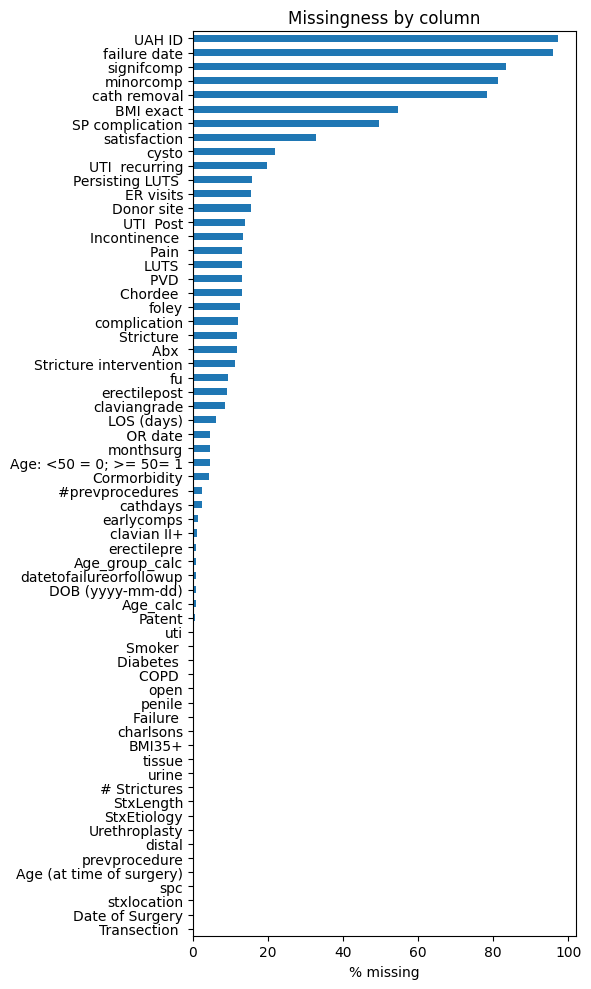

In [19]:
plt.figure(figsize=(6,10))
(df.isna().mean().mul(100)
   .sort_values()
   .plot(kind="barh"))
plt.xlabel("% missing")
plt.title("Missingness by column")
plt.tight_layout()
plt.show()

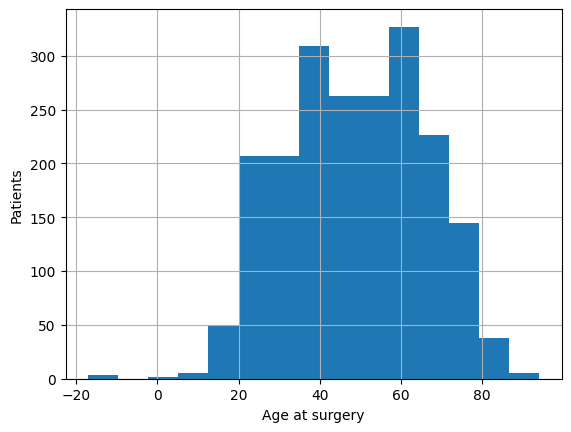

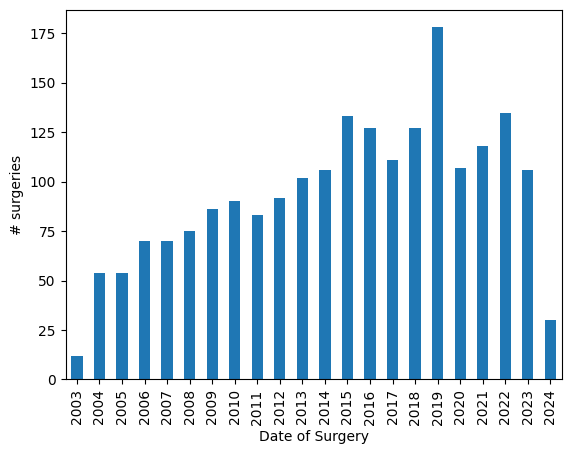

In [20]:
df["Age_calc"].hist(bins=15)
plt.xlabel("Age at surgery"); plt.ylabel("Patients"); plt.show()

# Surgery count per year
(df["Date of Surgery"].dt.year
     .value_counts()
     .sort_index()
     .plot(kind="bar"))
plt.ylabel("# surgeries"); plt.show()



In [21]:
df.columns

Index(['UAH ID', 'DOB (yyyy-mm-dd)', 'Date of Surgery', 'monthsurg',
       'Age (at time of surgery)', 'Age: <50 = 0; >= 50= 1', 'stxlocation',
       'distal', 'penile', 'StxEtiology', 'StxLength', '# Strictures',
       'charlsons', 'Cormorbidity', 'Diabetes ', 'COPD ', 'Smoker ', 'BMI35+',
       'BMI exact', 'prevprocedure', '#prevprocedures ', 'cysto', 'open',
       ' OR date', 'urine', 'Abx ', 'erectilepre', 'uti', 'LOS (days)', 'spc',
       'tissue', 'Transection ', 'Urethroplasty', 'cath removal', 'cathdays',
       'Failure ', 'Patent', 'fu', 'failure date', 'datetofailureorfollowup',
       'complication', 'clavian II+', 'claviangrade', 'earlycomps',
       'signifcomp', 'minorcomp', 'ER visits', 'foley', 'SP complication',
       'erectilepost', 'Pain ', 'Chordee ', 'PVD ', 'Donor site', 'UTI  Post',
       'UTI  recurring', 'LUTS ', 'Persisting LUTS ', 'Incontinence ',
       'Stricture ', 'Stricture intervention', 'satisfaction', 'Age_calc',
       'Age_group_calc'],
  

In [211]:
def try_length(val):
    txt = str(val).lower().replace(",", ".").strip()
    nums = re.findall(r"\d*\.?\d+", txt)
    return np.nan if len(nums) == 0 else sum(map(float, nums))

stx_numeric = df["StxLength"].apply(try_length)

In [212]:
df_len = df.assign(StxLength_cm=stx_numeric)
rows_before = len(df_len)
df_len = df_len.dropna(subset=["StxLength_cm"])   # keep only numeric rows
rows_after = len(df_len)

print(f"Skipped {rows_before - rows_after} rows with non-numeric StxLength")

Skipped 1 rows with non-numeric StxLength


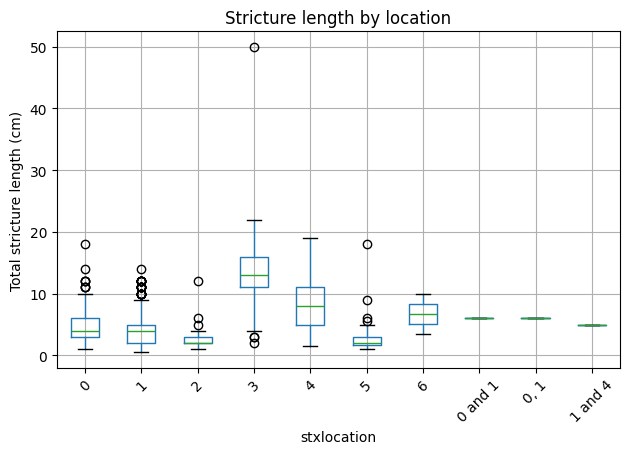

In [213]:
df_len.boxplot(column="StxLength_cm", by="stxlocation", rot=45)
plt.ylabel("Total stricture length (cm)")
plt.title("Stricture length by location")
plt.suptitle("")
plt.tight_layout()
plt.show()

<Figure size 40000x40000 with 0 Axes>

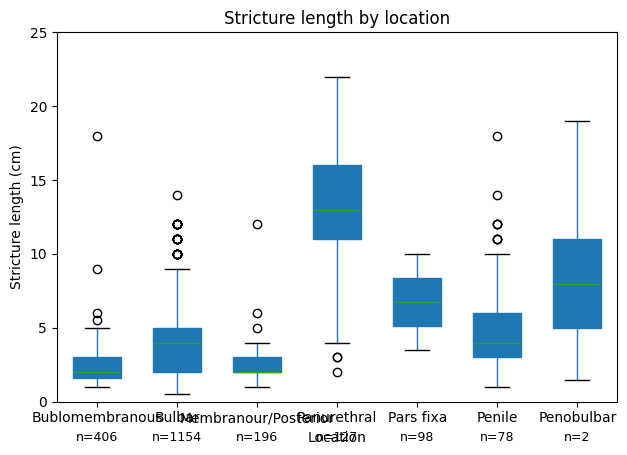

In [214]:
#  Keep rows with a **single** numeric location (skip combos)
is_single_num = df_len["stxlocation"].astype(str).str.fullmatch(r"\d")
df_plot = df_len[is_single_num].copy()

# Legend:StxLocation LEGEND: 0=penile, 1=bulbar, 2= membranous/posterior, 3=panurethral, 4= penobulbar, 5= bulbomembranous, 6 = pars fixa

loc_map = {
    "0": "Penile",
    "1": "Bulbar",
    "2": "Membranour/Posterior",
    "3": "Panurethral",
    "4": "Penobulbar",
    "5": "Bublomembranous",
    "6": "Pars fixa",
}

df_plot["Location"] = df_plot["stxlocation"].astype(str).map(loc_map)
# Only keep rows with a single numeric location (skip combos)
is_single_num = df_len["stxlocation"].astype(str).str.fullmatch(r"\d")
df_plot = df_len[is_single_num].copy()
df_plot["Location"] = df_plot["stxlocation"].astype(str).map(loc_map)


# Ordered categories → nicer x-axis, hide one crazy outliers bc why not
order = ["Penile", "Bulbar", "Membranour/Posterior",
         "Panurethral", "Penobulbar", "Bublomembranous", "Pars fixa"]



plt.figure(figsize=(400,400))
ax = df_plot.boxplot(
    column="StxLength_cm",
    by="Location",
    grid=False,
    widths=0.6,
    showcaps=True,
    showfliers=True,
    patch_artist=True,
)
plt.ylabel("Stricture length (cm)")
plt.title("Stricture length by location")
#plt.xticks(rotation=30)
plt.suptitle("")
plt.ylim(0, 25)
plt.tight_layout()

# Show sample size under each box
group_counts = df_plot.groupby("Location")["StxLength_cm"].count()
for i, loc in enumerate(order):
    n = group_counts.get(loc, 0)
    plt.text(i + 1, -2, f"n={n}", ha="center", va="top", fontsize=9)

plt.show()

In [215]:
# Reuse cleaned location dataframe
df_fail = df_len[is_single_num].copy()
df_fail["Location"] = df_fail["stxlocation"].astype(str).map(loc_map)
df_fail["Location"] = pd.Categorical(df_fail["Location"], categories=order, ordered=True)

# Make sure Failure is numeric (0/1)
fail_map = {
    "Yes": 1, "Y": 1, "1": 1, True: 1, 1: 1,
    "No": 0, "N": 0, "0": 0, False: 0, 0: 0,
    "not done": pd.NA, "pending": pd.NA, "Not Done": pd.NA, "": pd.NA, None: pd.NA
}
df_fail["Failure_bin"] = df_fail["Failure "].replace(fail_map)
df_fail = df_fail[df_fail["Failure_bin"].notna()]
df_fail["Failure_bin"] = df_fail["Failure_bin"].astype("Int8")

In [216]:
print(df_fail["Failure_bin"].value_counts(dropna=False))
print(df_fail["Failure "].unique())


Failure_bin
0    1866
1     179
2       2
Name: count, dtype: Int64
[0 1 2]


In [217]:
print(df_fail[df_fail["Failure_bin"] == 2])
print(df_fail["Failure "].unique())

     UAH ID DOB (yyyy-mm-dd) Date of Surgery  monthsurg  \
1979    NaN       1962-07-05      2023-05-15        NaN   
1981    NaN       2002-08-07      2023-05-29       24.0   

      Age (at time of surgery) Age: <50 = 0; >= 50= 1 stxlocation  distal  \
1979                      60.0                    NaN           3     1.0   
1981                      20.0                      0           1     0.0   

      penile StxEtiology  ... Persisting LUTS   Incontinence   Stricture   \
1979     1.0           2  ...                0              0           0   
1981     0.0           0  ...              NaN              0         NaN   

      Stricture intervention satisfaction Age_calc Age_group_calc  \
1979                       0            1       60          50-59   
1981                     NaN            1       20            <30   

      StxLength_cm     Location  Failure_bin  
1979          14.0  Panurethral            2  
1981           5.0       Bulbar            2  

[2 rows 

CLEANING STUFF

In [218]:
#My attempt at replacing empty cells with 0's in their cysto column
df["cysto"] = df["cysto"].replace(
    ['', 'n/a', 'N/A', None, pd.NA], 0
).fillna(0)


In [219]:
#Cleaning up the abx columm,
#Yes = 1
#No = 0
df["Abx "] = df["Abx "].replace(
    ['yes','Yes','YES'], 1
)
df["Abx "] = df["Abx "].replace(
    ['no record','No records','', 'n/a', 'N/A', None, pd.NA], 0
).fillna(0)



In [242]:
#Cleaning up the smoker column 
def encode_smoker(val):
    if pd.isna(val) or str(val).strip().lower() in ['', 'not recorded', 'n/a', 'none']:
        return 0  # treat empty/NA as non-smoker
    v = str(val).strip().lower()
    if v in ['0', 'no', 'non smoker', 'non-smoker', 'nonsmoker']:
        return 0
    elif 'ex' in v or 'former' in v:
        return 1
    elif v in ['2', 'yes', 'smoker', 'current smoker', '1']:
        return 1
    else:
        return 0  # fallback: treat any odd/unexpected entry as non-smoker



In [243]:
df['smoker_status'] = df['Smoker '].apply(encode_smoker).astype('Int8')


In [244]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2066 entries, 0 to 2065
Data columns (total 66 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   UAH ID                    59 non-null     object        
 1   DOB (yyyy-mm-dd)          2050 non-null   datetime64[ns]
 2   Date of Surgery           2066 non-null   datetime64[ns]
 3   monthsurg                 1973 non-null   float64       
 4   Age (at time of surgery)  2065 non-null   float64       
 5   Age: <50 = 0; >= 50= 1    1973 non-null   object        
 6   stxlocation               2066 non-null   object        
 7   distal                    2065 non-null   float64       
 8   penile                    2064 non-null   float64       
 9   StxEtiology               2065 non-null   object        
 10  StxLength                 2065 non-null   object        
 11  # Strictures              2065 non-null   float64       
 12  charlsons           

In [245]:
df["datetofailureorfollowup"] = df["datetofailureorfollowup"].replace(
    ['', 'n/a', 'N/A', 'No FU', None, pd.NA], 0
).fillna(0).astype('float64'
)

In [246]:
print(df['datetofailureorfollowup'])

0        49.0
1       212.0
2       212.0
3        60.0
4       212.0
        ...  
2061      0.0
2062      0.0
2063      0.0
2064      0.0
2065      0.0
Name: datetofailureorfollowup, Length: 2066, dtype: float64


In [247]:
df['datetofailureorfollowup'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 2066 entries, 0 to 2065
Series name: datetofailureorfollowup
Non-Null Count  Dtype  
--------------  -----  
2066 non-null   float64
dtypes: float64(1)
memory usage: 16.3 KB


In [226]:
df['Failure_bin'] = df['Failure '].replace(fail_map).astype("Int8")

In [227]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

In [228]:

from lifelines import KaplanMeierFitter

In [248]:
df_smoker = df.copy()

df_smoker['datetofailureorfollowup'] = pd.to_numeric(df['datetofailureorfollowup'], errors='coerce')
# Ensure event column is integer 0 or 1
df_smoker['Failure '] = pd.to_numeric(df_smoker['Failure ' ], errors='coerce').astype('Int8')

df_smoker = df_smoker.dropna(subset=['datetofailureorfollowup', 'Failure '])


In [249]:
print(df_smoker['Failure '])

0       0
1       0
2       0
3       1
4       0
       ..
2047    0
2048    0
2049    0
2051    0
2055    0
Name: Failure , Length: 2050, dtype: Int8


In [252]:
group_labels = {0: 'Non-smoker', 1: 'Ex-smoker & Smoker'}

# Only include groups you care about and that have enough samples
for status in [0, 1]:
    mask = df_smoker['smoker_status'] == status
    print(f"{group_labels[status]}: {mask.sum()} patients")

Non-smoker: 1550 patients
Ex-smoker & Smoker: 500 patients


In [253]:
print(df_smoker['datetofailureorfollowup'])

0        49.000000
1       212.000000
2       212.000000
3        60.000000
4       212.000000
           ...    
2047      2.066667
2048      1.000000
2049      0.000000
2051      3.100000
2055      0.000000
Name: datetofailureorfollowup, Length: 2050, dtype: float64


In [254]:
df.to_excel("new_data_with_smoker.xlsx", index=False)


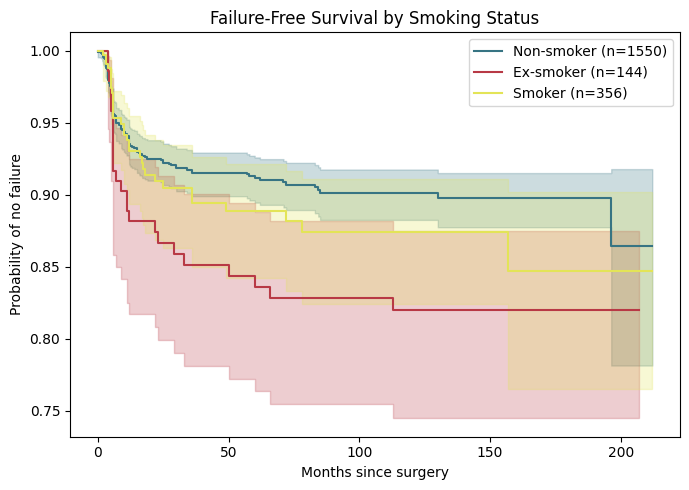

In [234]:
plt.figure(figsize=(7,5))
kmf = KaplanMeierFitter()
colors = ['#377483', '#b83945', '#e3e457']

for idx, status in enumerate([0, 1, 2]):
    mask = df_smoker['smoker_status'] == status
    if mask.sum() < 5:
        continue  # skip tiny groups
    T = df_smoker.loc[mask, 'datetofailureorfollowup']
    E = df_smoker.loc[mask, 'Failure ']
    kmf.fit(T, event_observed=E, label=f"{group_labels[status]} (n={mask.sum()})")
    kmf.plot_survival_function(ci_show=True, color=colors[idx])

plt.title('Failure-Free Survival by Smoking Status')
plt.xlabel('Months since surgery')
plt.ylabel('Probability of no failure')
plt.legend()
plt.tight_layout()
plt.show()

In [235]:
print(df_smoker['datetofailureorfollowup'].min())

0.0


In [106]:
from lifelines.statistics import logrank_test

mask0 = df_smoker['smoker_status'] == 0
mask1 = df_smoker['smoker_status'] == 1
mask2 = df_smoker['smoker_status'] == 2

results = logrank_test(
    df_smoker.loc[mask0, 'datetofailureorfollowup'],
    df_smoker.loc[mask1, 'datetofailureorfollowup'],
    df_smoker.loc[mask2, 'datetofailureorfollowup'],
    event_observed_A=df_smoker.loc[mask0, 'Failure '],
    event_observed_B=df_smoker.loc[mask1, 'Failure '],
    event_observed_C=df_smoker.loc[mask2, 'Failure ']
)
results.print_summary()

TypeError: logrank_test() got multiple values for argument 'event_observed_A'

In [ ]:
group0 = df_smoker[df_smoker['smoker_status'] == 0]   # Non-smoker
group1 = df_smoker[df_smoker['smoker_status'] == 1]   # Ex-smoker
group2 = df_smoker[df_smoker['smoker_status'] == 2]   # Smoker

In [87]:
df.to_excel("cleaned_data_with_smoker.xlsx", index=False)
